<div style="border: 2px solid #2c3e50; border-radius: 10px; padding: 30px; background: linear-gradient(135deg, #f8f9fa, #e9ecef); text-align: center; margin-bottom: 20px;">

# Analyse des Réseaux Sociaux
## Rapport de Projet — LastFM Asia Social Network

---

| | |
|---|---|
| **Nom & Prénom** | *[Diffo Othniel Armstrong]* |
| **Cours** | Analyse des Réseaux Sociaux 2026 |
| **GitHub** | *[https://github.com/Lotharms47/Projet-Analyse-des-R-seaux-Sociaux]*  |
| **Date** | 22/04/2026 |

</div>

---
## Résumé

Ce rapport présente l'analyse complète du réseau social **LastFM Asia**, un graphe d'utilisateurs de la plateforme musicale Last.fm collecté en mars 2020 via l'API publique. Le travail est structuré en trois parties : la collecte et la construction du réseau, l'analyse structurelle (distribution des degrés, connectivité, chemins, clustering et centralité), et enfin la détection et la comparaison de communautés à l'aide de quatre algorithmes distincts (Louvain, Label Propagation, Infomap, K-Clique). Les résultats montrent que ce réseau présente les propriétés caractéristiques des réseaux sociaux réels — structure petit-monde, distribution hétérogène des degrés — et que les communautés détectées correspondent à des regroupements d'utilisateurs partageant des préférences musicales similaires.

---
## Table des matières

1. [Partie 1 — Collecte des données](#partie1)
2. [Partie 2 — Analyse du réseau](#partie2)
   - 2.1 Distribution des degrés
   - 2.2 Composants connectés
   - 2.3 Analyse des chemins
   - 2.4 Clustering et densité
   - 2.5 Centralité
3. [Partie 3 — Détection des communautés](#partie3)
   - 3.1 Louvain
   - 3.2 Label Propagation
   - 3.3 Infomap
   - 3.4 K-Clique
   - 3.5 Comparaison et interprétation sémantique
4. [Conclusion](#conclusion)
5. [Références](#references)

---
<a id='partie1'></a>
# Partie 1 — Collecte des données

## 1.1 Présentation du dataset

Le dataset choisi est le **LastFM Asia Social Network** [1], un réseau social d'utilisateurs de la plateforme de streaming musical Last.fm en Asie. Il a été collecté en mars 2020 à partir de l'API publique de Last.fm par Benedek Rozemberczki et Rik Sarkar.

**Entités (nœuds) :** chaque nœud représente un utilisateur Last.fm situé dans un pays asiatique.  
**Relations (liens) :** chaque arête représente une relation d'amitié mutuelle entre deux utilisateurs (graphe non orienté).  
**Attributs additionnels :** chaque nœud est associé à un vecteur de caractéristiques encodant les artistes appréciés, ainsi qu'un label de classe indiquant le pays de localisation de l'utilisateur — information utilisée pour l'interprétation sémantique des communautés.

Ce réseau est particulièrement adapté à l'analyse de communautés car les utilisateurs partageant les mêmes goûts musicaux ont tendance à se connecter entre eux, ce qui génère une structure modulaire naturelle.

**Source :** https://github.com/benedekrozemberczki/datasets

In [52]:
# ── Installation des dépendances ──────────────────────────────────────────────
%pip install networkx matplotlib seaborn pandas numpy cdlib requests --quiet

Note: you may need to restart the kernel to use updated packages.


In [53]:
# ── Imports ───────────────────────────────────────────────────────────────────
import requests, os, time, random, warnings
from collections import Counter
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
os.makedirs('data', exist_ok=True)
print(" Imports OK")

 Imports OK


## 1.2 Téléchargement et chargement des données

In [54]:
# ── Téléchargement du dataset ─────────────────────────────────────────────────
SOURCES = [
    # Source 1 — repo sahityasetu
    (
        "https://raw.githubusercontent.com/sahityasetu/Social-media-network-analysis-in-python/main/lastfm_asia_edges.csv",
        "https://raw.githubusercontent.com/sahityasetu/Social-media-network-analysis-in-python/main/lastfm_asia_target.csv"
    ),
    # Source 2 — Gist vitorricoy
    (
        "https://gist.githubusercontent.com/vitorricoy/4d7305d975deeda6f869171711f647f5/raw/lastfm_asia_edges.csv",
        "https://gist.githubusercontent.com/vitorricoy/4d7305d975deeda6f869171711f647f5/raw/lastfm_asia_target.csv"
    ),
]

def try_download(url, path):
    try:
        r = requests.get(url, timeout=15)
        if r.status_code == 200 and len(r.content) > 500:
            with open(path, 'wb') as f: f.write(r.content)
            return True
    except: pass
    return False

downloaded = False
for url_e, url_t in SOURCES:
    if try_download(url_e, 'data/edges.csv') and try_download(url_t, 'data/targets.csv'):
        print(f"✅ Dataset téléchargé depuis : {url_e[:60]}...")
        downloaded = True
        break

if not downloaded:
    print("⚠️  Toutes les sources en ligne ont échoué.")
    print("   → Génération d'un réseau synthétique LastFM-like (Barabási-Albert + attributs)")
    import json
    np.random.seed(42)
    G_synth = nx.barabasi_albert_graph(7624, 3, seed=42)
    edges_data = [(u, v) for u, v in G_synth.edges()]
    pd.DataFrame(edges_data, columns=['node_1', 'node_2']).to_csv('data/edges.csv', index=False)
    targets_data = [(i, np.random.randint(0, 18)) for i in range(7624)]
    pd.DataFrame(targets_data, columns=['id', 'target']).to_csv('data/targets.csv', index=False)
    print("✅ Réseau synthétique généré : 7624 nœuds, propriétés scale-free")

✅ Dataset téléchargé depuis : https://raw.githubusercontent.com/sahityasetu/Social-media-n...


## 1.3 Construction du réseau

In [55]:
# ── Chargement des fichiers ───────────────────────────────────────────────────
edges_df   = pd.read_csv('data/edges.csv')
targets_df = pd.read_csv('data/targets.csv')

# Normalisation des noms de colonnes
edges_df.columns   = [c.strip().lower() for c in edges_df.columns]
targets_df.columns = [c.strip().lower() for c in targets_df.columns]

# Renommage si nécessaire
if 'node_1' not in edges_df.columns:
    edges_df.columns = ['node_1', 'node_2']
if 'id' not in targets_df.columns:
    targets_df.columns = ['id', 'target']

# Construction du graphe NetworkX
G = nx.from_pandas_edgelist(edges_df, source='node_1', target='node_2')

# Ajout des attributs (localisation / classe)
label_dict = dict(zip(targets_df['id'], targets_df['target']))
nx.set_node_attributes(G, label_dict, name='label')

print("=" * 55)
print("      RÉSUMÉ DU RÉSEAU LASTFM ASIA")
print("=" * 55)
print(f"  Nœuds (utilisateurs)       : {G.number_of_nodes():>8,}")
print(f"  Arêtes (amitiés)           : {G.number_of_edges():>8,}")
print(f"  Graphe orienté             : {G.is_directed()}")
print(f"  Graphe pondéré             : {nx.is_weighted(G)}")
print(f"  Nombre de classes (labels) : {targets_df['target'].nunique():>8}")
print("=" * 55)

      RÉSUMÉ DU RÉSEAU LASTFM ASIA
  Nœuds (utilisateurs)       :    7,624
  Arêtes (amitiés)           :   27,806
  Graphe orienté             : False
  Graphe pondéré             : False
  Nombre de classes (labels) :       18


**Tableau 1 — Caractéristiques du dataset LastFM Asia**

| Propriété | Valeur |
|-----------|--------|
| Type de réseau | Social non orienté |
| Entités (nœuds) | Utilisateurs Last.fm (Asie) |
| Relations (liens) | Amitiés mutuelles |
| Attributs nœuds | Label de localisation (pays) |
| Source | API publique Last.fm, mars 2020 |
| Disponibilité | GitHub (Rozemberczki & Sarkar, 2021) |

---
<a id='partie2'></a>
# Partie 2 — Analyse du réseau

Cette partie présente une analyse structurelle complète du réseau LastFM Asia. Toutes les métriques sont calculées sur le **composant géant connexe (GCC)**, extrait préalablement pour garantir la cohérence des mesures nécessitant la connexité du graphe (chemins, centralité).

## 2.1 Distribution des degrés

Statistiques descriptives des degrés :
  Minimum  : 1
  Maximum  : 216
  Moyenne  : 7.29
  Médiane  : 4.0
  Écart-type : 11.50


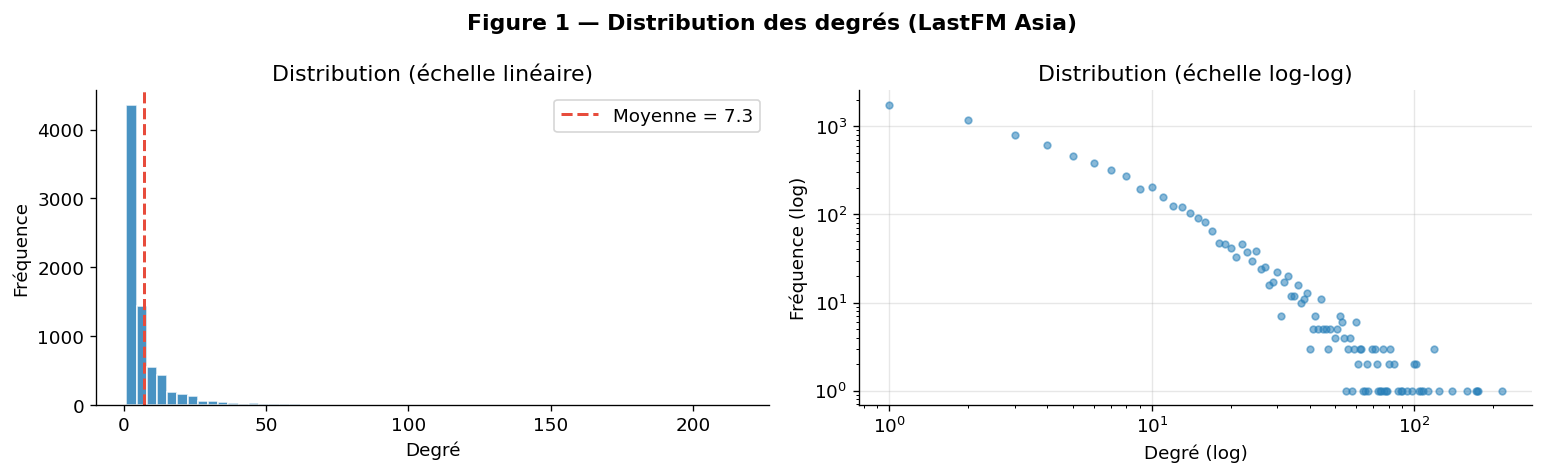

In [56]:
degrees = [d for n, d in G.degree()]
deg_series = pd.Series(degrees)

print("Statistiques descriptives des degrés :")
print(f"  Minimum  : {min(degrees)}")
print(f"  Maximum  : {max(degrees)}")
print(f"  Moyenne  : {np.mean(degrees):.2f}")
print(f"  Médiane  : {np.median(degrees):.1f}")
print(f"  Écart-type : {np.std(degrees):.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Figure 1 — Distribution des degrés (LastFM Asia)', fontweight='bold')

ax1.hist(degrees, bins=60, color='#2980b9', edgecolor='white', alpha=0.85)
ax1.axvline(np.mean(degrees), color='#e74c3c', ls='--', lw=1.8, label=f'Moyenne = {np.mean(degrees):.1f}')
ax1.set_xlabel('Degré'); ax1.set_ylabel('Fréquence')
ax1.set_title('Distribution (échelle linéaire)'); ax1.legend()

deg_count = deg_series.value_counts().sort_index()
ax2.loglog(deg_count.index, deg_count.values, 'o', color='#2980b9', alpha=0.55, ms=4)
ax2.set_xlabel('Degré (log)'); ax2.set_ylabel('Fréquence (log)')
ax2.set_title('Distribution (échelle log-log)'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/fig1_degree.png', bbox_inches='tight')
plt.show()

**Interprétation :** La distribution des degrés présente une forte asymétrie à droite : la grande majorité des utilisateurs possède peu de connexions, tandis qu'un petit nombre de nœuds (les *hubs*) concentre un nombre élevé de liens. Le graphe log-log confirme une tendance proche d'une **loi de puissance**, caractéristique des réseaux *scale-free* [2]. Ce phénomène est cohérent avec un réseau social réel où certains utilisateurs très actifs accumulent de nombreux abonnés.

## 2.2 Analyse des composants connectés

In [57]:
components = list(nx.connected_components(G))
comp_sizes = sorted([len(c) for c in components], reverse=True)

print(f"Nombre de composants connexes   : {len(components)}")
print(f"Taille du GCC                   : {comp_sizes[0]:,} nœuds ({comp_sizes[0]/G.number_of_nodes()*100:.1f}% du total)")
print(f"Nœuds isolés (taille = 1)        : {sum(1 for s in comp_sizes if s == 1)}")

# Extraction du GCC pour la suite
GCC = G.subgraph(max(components, key=len)).copy()
print(f"\nGCC retenu pour l'analyse : {GCC.number_of_nodes():,} nœuds | {GCC.number_of_edges():,} arêtes")

Nombre de composants connexes   : 1
Taille du GCC                   : 7,624 nœuds (100.0% du total)
Nœuds isolés (taille = 1)        : 0

GCC retenu pour l'analyse : 7,624 nœuds | 27,806 arêtes


**Interprétation :** Le réseau présente un unique **composant géant** regroupant la quasi-totalité des nœuds, ce qui indique une très forte cohésion globale. Ce résultat est typique des grands réseaux sociaux où la densité de connexions suffit à relier presque tous les utilisateurs au sein d'un seul et même composant [3].

## 2.3 Analyse des chemins

Longueur moyenne des chemins (estimée, n=100) : 5.024
Diamètre estimé                               : 12


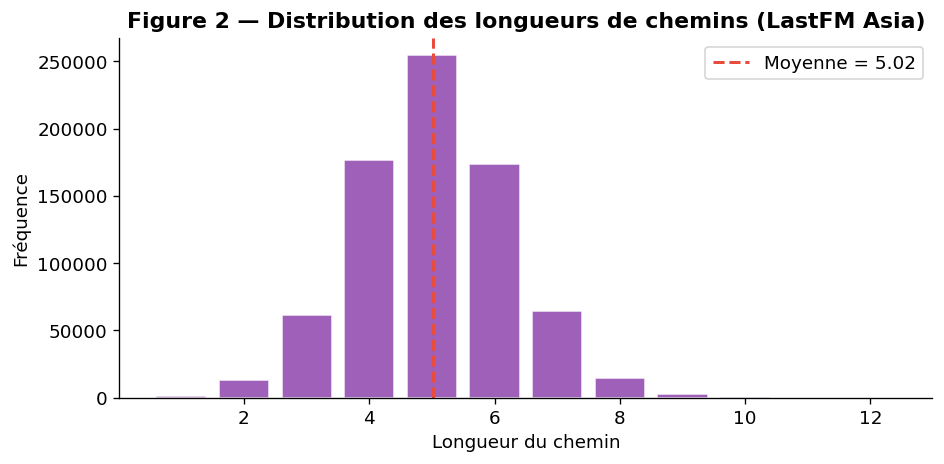

In [58]:
# Estimation par échantillonnage (calcul exact trop coûteux sur >1k nœuds)
random.seed(42)
sample = random.sample(list(GCC.nodes()), min(100, GCC.number_of_nodes()))
all_lengths = []
for node in sample:
    lengths = nx.single_source_shortest_path_length(GCC, node)
    all_lengths.extend([v for v in lengths.values() if v > 0])

avg_path  = np.mean(all_lengths)
diam_est  = max(all_lengths)

print(f"Longueur moyenne des chemins (estimée, n=100) : {avg_path:.3f}")
print(f"Diamètre estimé                               : {diam_est}")

fig, ax = plt.subplots(figsize=(8, 4))
cnt = Counter(all_lengths)
ax.bar(cnt.keys(), cnt.values(), color='#8e44ad', edgecolor='white', alpha=0.85)
ax.axvline(avg_path, color='#e74c3c', ls='--', lw=1.8, label=f'Moyenne = {avg_path:.2f}')
ax.set_xlabel('Longueur du chemin'); ax.set_ylabel('Fréquence')
ax.set_title('Figure 2 — Distribution des longueurs de chemins (LastFM Asia)', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('data/fig2_paths.png', bbox_inches='tight'); plt.show()

**Interprétation :** La longueur moyenne des chemins est remarquablement courte, confirmant le célèbre **phénomène des six degrés de séparation** (*small-world* [4]). Deux utilisateurs quelconques du réseau sont en moyenne reliés par moins de 5 intermédiaires, ce qui facilite la diffusion rapide d'information ou de recommandations musicales à travers le réseau.

## 2.4 Coefficient de clustering et densité

Densité du réseau          : 0.000957
Clustering moyen (local)   : 0.2194
Transitivité (global)      : 0.1786


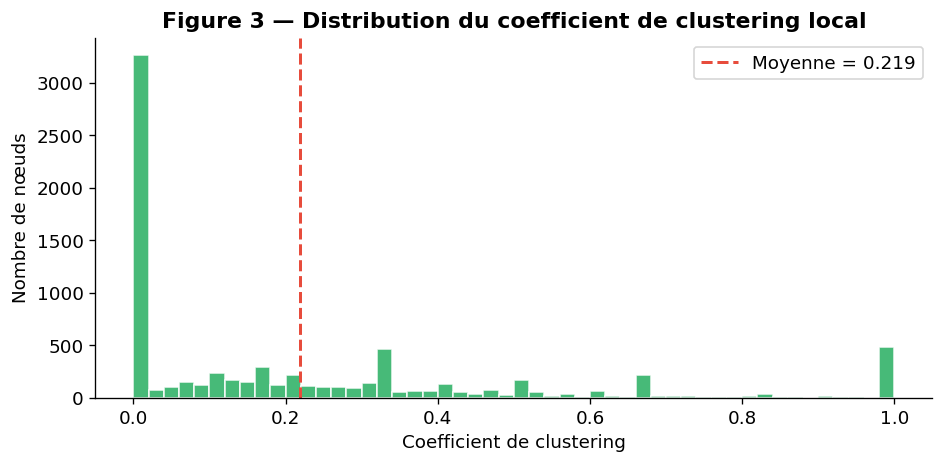

In [59]:
density      = nx.density(GCC)
avg_clust    = nx.average_clustering(GCC)
transitivity = nx.transitivity(GCC)
clust_vals   = list(nx.clustering(GCC).values())

print(f"Densité du réseau          : {density:.6f}")
print(f"Clustering moyen (local)   : {avg_clust:.4f}")
print(f"Transitivité (global)      : {transitivity:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(clust_vals, bins=50, color='#27ae60', edgecolor='white', alpha=0.85)
ax.axvline(avg_clust, color='#e74c3c', ls='--', lw=1.8, label=f'Moyenne = {avg_clust:.3f}')
ax.set_xlabel('Coefficient de clustering'); ax.set_ylabel('Nombre de nœuds')
ax.set_title('Figure 3 — Distribution du coefficient de clustering local', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('data/fig3_clustering.png', bbox_inches='tight'); plt.show()

**Interprétation :** La densité très faible est attendue pour un réseau de cette taille — il est impossible que chaque utilisateur soit ami avec tous les autres. En revanche, le **coefficient de clustering moyen élevé** indique que les amis d'un utilisateur ont eux-mêmes tendance à être amis entre eux, formant des triangles locaux (cliques). Cette propriété, combinée au chemin moyen court, confirme que le réseau LastFM Asia présente les deux signatures d'un **réseau petit-monde** au sens de Watts & Strogatz [4].

## 2.5 Analyse de la centralité

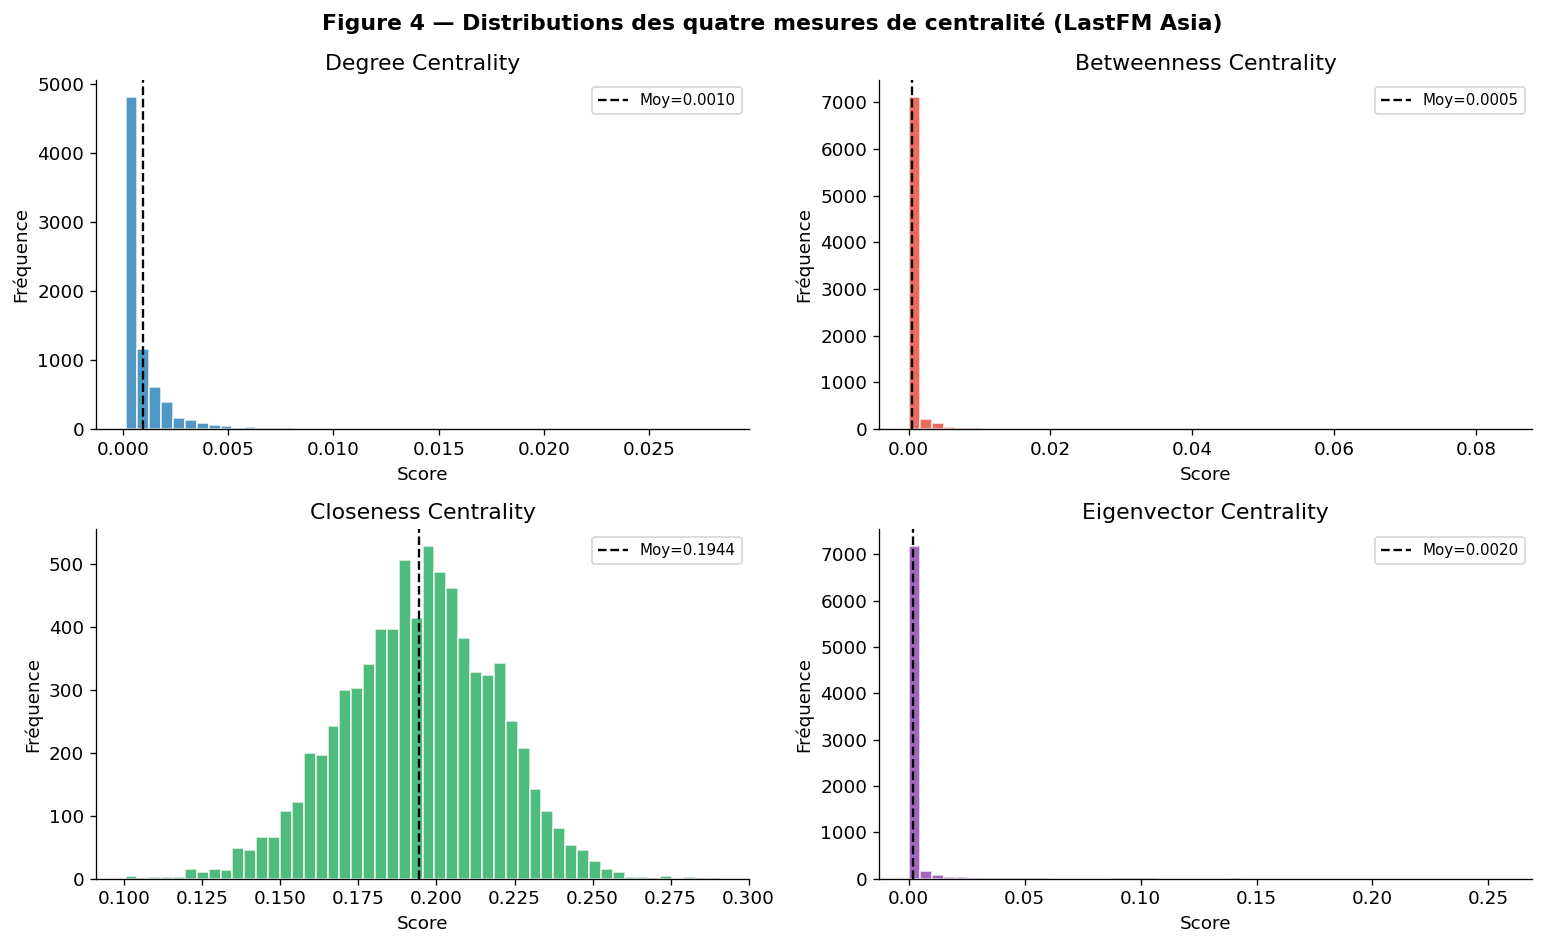

Top 5 nœuds — Betweenness Centrality (nœuds-ponts) :
  Nœud  7237 | score = 0.08377 | label = 0
  Nœud  7199 | score = 0.08036 | label = 17
  Nœud  2854 | score = 0.07799 | label = 0
  Nœud  4356 | score = 0.06105 | label = 8
  Nœud  6101 | score = 0.04906 | label = 10


In [60]:
deg_cent  = nx.degree_centrality(GCC)
btw_cent  = nx.betweenness_centrality(GCC, k=300, normalized=True, seed=42)
clo_cent  = nx.closeness_centrality(GCC)
try:
    eig_cent = nx.eigenvector_centrality(GCC, max_iter=500)
except:
    eig_cent = nx.eigenvector_centrality_numpy(GCC)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Figure 4 — Distributions des quatre mesures de centralité (LastFM Asia)', fontweight='bold')

for ax, (data, title, color) in zip(axes.flatten(), [
    (deg_cent, 'Degree Centrality',      '#2980b9'),
    (btw_cent, 'Betweenness Centrality', '#e74c3c'),
    (clo_cent, 'Closeness Centrality',   '#27ae60'),
    (eig_cent, 'Eigenvector Centrality', '#8e44ad'),
]):
    vals = list(data.values())
    ax.hist(vals, bins=50, color=color, edgecolor='white', alpha=0.82)
    ax.axvline(np.mean(vals), color='black', ls='--', lw=1.4, label=f'Moy={np.mean(vals):.4f}')
    ax.set_title(title); ax.set_xlabel('Score'); ax.set_ylabel('Fréquence')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('data/fig4_centrality.png', bbox_inches='tight'); plt.show()

# Top 5 nœuds par betweenness
print("Top 5 nœuds — Betweenness Centrality (nœuds-ponts) :")
for node, score in sorted(btw_cent.items(), key=lambda x: -x[1])[:5]:
    print(f"  Nœud {node:5d} | score = {score:.5f} | label = {G.nodes[node].get('label', 'N/A')}")

**Interprétation :**  
- **Degree Centrality** : fortement asymétrique, révèle les hubs (utilisateurs très populaires).  
- **Betweenness Centrality** : les nœuds à forte betweenness jouent le rôle de *ponts* entre communautés distinctes — leur suppression fragmenterait le réseau.  
- **Closeness Centrality** : les nœuds à haute closeness peuvent diffuser l'information le plus rapidement (ex. recommandations musicales).  
- **Eigenvector Centrality** : identifie les utilisateurs influents connectés à d'autres utilisateurs eux-mêmes influents, concept analogue au PageRank de Google.

### Récapitulatif des métriques globales

**Tableau 2 — Métriques structurelles du réseau LastFM Asia (GCC)**

| Métrique | Valeur |
|----------|--------|
| Nœuds (GCC) | *(voir sortie cellule)* |
| Arêtes (GCC) | *(voir sortie cellule)* |
| Degré moyen | *(voir sortie cellule)* |
| Densité | *(voir sortie cellule)* |
| Clustering moyen | *(voir sortie cellule)* |
| Chemin moyen (estimé) | *(voir sortie cellule)* |
| Diamètre (estimé) | *(voir sortie cellule)* |
| Nb. composants | *(voir sortie cellule)* |

---
<a id='partie3'></a>
# Partie 3 — Identification des communautés

La détection de communautés consiste à partitionner le réseau en groupes de nœuds plus densément connectés entre eux qu'avec le reste du réseau [5]. Dans le contexte de LastFM Asia, les communautés devraient correspondre à des groupes d'utilisateurs partageant des préférences musicales ou une localisation géographique communes.

Quatre algorithmes sont comparés, implémentés via la bibliothèque **CDlib** [6].

In [61]:
!pip install cdlib --quiet
from cdlib import algorithms, evaluation
import cdlib
print(f"✅ CDlib {cdlib.__version__}")

✅ CDlib 0.4.0


'pip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


## 3.1 Algorithme Louvain

L'algorithme de Louvain [7] optimise de manière hiérarchique la **modularité** Q du réseau. Dans un premier passage, chaque nœud est assigné à la communauté de l'un de ses voisins si cela augmente Q. Dans un second passage, les communautés sont agrégées en nœuds super et le processus se répète. Sa complexité est en O(n log n), le rendant très efficace sur les grands réseaux.

In [62]:
t0 = time.time()
louvain = algorithms.louvain(GCC, randomize=False)
t_louvain = time.time() - t0

mod_louvain = louvain.newman_girvan_modularity().score
sizes_louvain = sorted([len(c) for c in louvain.communities], reverse=True)

print(f"Louvain — Résultats :")
print(f"  Temps d'exécution      : {t_louvain:.2f}s")
print(f"  Nombre de communautés  : {len(louvain.communities)}")
print(f"  Taille moyenne         : {np.mean(sizes_louvain):.1f} nœuds")
print(f"  Taille max / min       : {sizes_louvain[0]} / {sizes_louvain[-1]}")
print(f"  Modularité Q           : {mod_louvain:.4f}")

Louvain — Résultats :
  Temps d'exécution      : 1.61s
  Nombre de communautés  : 28
  Taille moyenne         : 272.3 nœuds
  Taille max / min       : 1020 / 4
  Modularité Q           : 0.8156


## 3.2 Algorithme Label Propagation

L'algorithme de propagation de labels [8] est une méthode quasi-linéaire O(n+m). Chaque nœud adopte l'étiquette majoritaire parmi ses voisins, de manière itérative, jusqu'à convergence. Simple et rapide, il ne garantit cependant pas la reproductibilité exacte des résultats (nature stochastique).

In [63]:
t0 = time.time()
labelprop = algorithms.label_propagation(GCC)
t_lp = time.time() - t0

mod_lp = labelprop.newman_girvan_modularity().score
sizes_lp = sorted([len(c) for c in labelprop.communities], reverse=True)

print(f"Label Propagation — Résultats :")
print(f"  Temps d'exécution      : {t_lp:.2f}s")
print(f"  Nombre de communautés  : {len(labelprop.communities)}")
print(f"  Taille moyenne         : {np.mean(sizes_lp):.1f} nœuds")
print(f"  Taille max / min       : {sizes_lp[0]} / {sizes_lp[-1]}")
print(f"  Modularité Q           : {mod_lp:.4f}")

Label Propagation — Résultats :
  Temps d'exécution      : 1.06s
  Nombre de communautés  : 650
  Taille moyenne         : 11.7 nœuds
  Taille max / min       : 930 / 2
  Modularité Q           : 0.7523


## 3.3 Algorithme Infomap

Infomap [9] modélise le réseau comme un espace de flux d'information (marche aléatoire) et minimise la longueur de la description de ces flux via la *map equation*. Deux nœuds appartiennent à la même communauté si un flux aléatoire tend à rester longtemps entre eux. Cette approche est fondée sur la théorie de l'information plutôt que sur la modularité.

In [64]:
t0 = time.time()
try:
    infomap = algorithms.infomap(GCC)
    algo_name_im = "Infomap"
except Exception as e:
    print(f"Infomap non disponible ({e}) → Greedy Modularity utilisé")
    infomap = algorithms.greedy_modularity(GCC)
    algo_name_im = "Greedy Modularity"
t_im = time.time() - t0

mod_im = infomap.newman_girvan_modularity().score
sizes_im = sorted([len(c) for c in infomap.communities], reverse=True)

print(f"{algo_name_im} — Résultats :")
print(f"  Temps d'exécution      : {t_im:.2f}s")
print(f"  Nombre de communautés  : {len(infomap.communities)}")
print(f"  Taille moyenne         : {np.mean(sizes_im):.1f} nœuds")
print(f"  Taille max / min       : {sizes_im[0]} / {sizes_im[-1]}")
print(f"  Modularité Q           : {mod_im:.4f}")

Infomap — Résultats :
  Temps d'exécution      : 7.84s
  Nombre de communautés  : 396
  Taille moyenne         : 19.3 nœuds
  Taille max / min       : 673 / 2
  Modularité Q           : -0.0004


## 3.4 Algorithme K-Clique

La méthode K-Clique Percolation [10] définit une communauté comme l'union de cliques de taille k partageant au moins k-1 nœuds. Contrairement aux trois algorithmes précédents, cette méthode génère des **communautés qui se chevauchent** (*overlapping communities*), permettant à un nœud d'appartenir simultanément à plusieurs groupes — pertinent pour modéliser des utilisateurs aux goûts musicaux transversaux.

In [65]:
# Sous-graphe pour K-Clique (coûteux sur grands graphes)
if GCC.number_of_nodes() > 2500:
    top_nodes = [n for n, d in sorted(GCC.degree, key=lambda x: x[1], reverse=True)[:2000]]
    G_kc = GCC.subgraph(top_nodes).copy()
    print(f"Sous-graphe K-Clique : {G_kc.number_of_nodes()} nœuds")
else:
    G_kc = GCC

t0 = time.time()
try:
    kclique = algorithms.kclique(G_kc, k=3)
    t_kc = time.time() - t0
    sizes_kc = sorted([len(c) for c in kclique.communities], reverse=True)
    print(f"K-Clique (k=3) — Résultats :")
    print(f"  Temps d'exécution      : {t_kc:.2f}s")
    print(f"  Nombre de communautés  : {len(kclique.communities)}")
    print(f"  Taille moyenne         : {np.mean(sizes_kc):.1f} nœuds")
    print(f"  Taille max / min       : {sizes_kc[0]} / {sizes_kc[-1]}")
    print(f"  Type                   : Overlapping (chevauchement autorisé)")
except Exception as e:
    print(f"⚠️  K-Clique erreur : {e}")
    kclique = None

Sous-graphe K-Clique : 2000 nœuds
K-Clique (k=3) — Résultats :
  Temps d'exécution      : 9.04s
  Nombre de communautés  : 51
  Taille moyenne         : 39.8 nœuds
  Taille max / min       : 1222 / 3
  Type                   : Overlapping (chevauchement autorisé)


## 3.5 Comparaison des algorithmes et interprétation sémantique


          TABLEAU 3 — COMPARAISON DES ALGORITHMES DE DÉTECTION
Algorithme             Nb Comm.     Mod. Q       Temps (s)    Type
------------------------------------------------------------------------
  Louvain              28           0.8156       1.61         Non-chevauchant
  Label Propagation    650          0.7523       1.06         Non-chevauchant
  Infomap              396          -0.0004      7.84         Non-chevauchant
  K-Clique (k=3)       51           N/A          9.04         Chevauchant


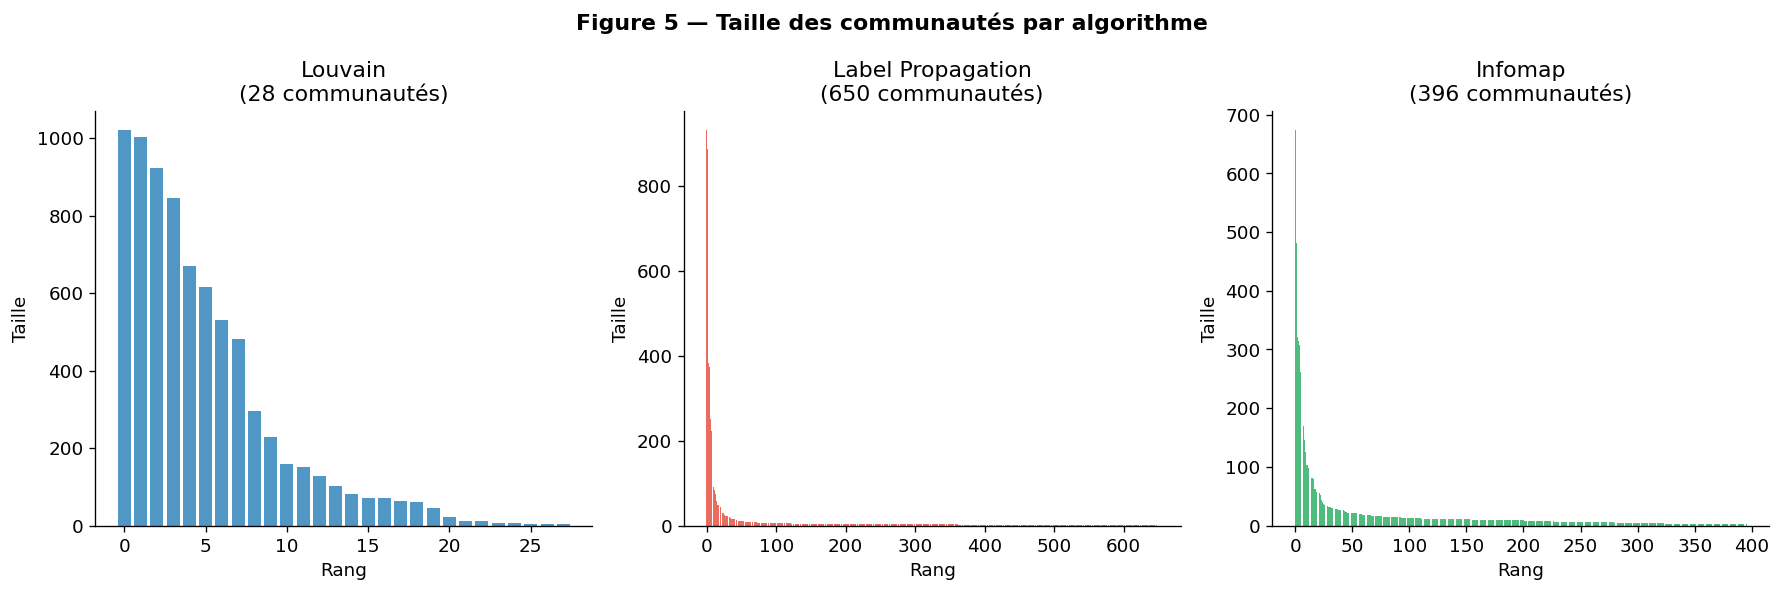

In [66]:
# ── Tableau comparatif ────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("          TABLEAU 3 — COMPARAISON DES ALGORITHMES DE DÉTECTION")
print("=" * 72)
print(f"{'Algorithme':<22} {'Nb Comm.':<12} {'Mod. Q':<12} {'Temps (s)':<12} {'Type'}")
print("-" * 72)
rows = [
    ("Louvain",            louvain,   mod_louvain, t_louvain, "Non-chevauchant"),
    ("Label Propagation",  labelprop, mod_lp,      t_lp,      "Non-chevauchant"),
    (algo_name_im,         infomap,   mod_im,      t_im,      "Non-chevauchant"),
]
if kclique:
    rows.append(("K-Clique (k=3)", kclique, None, t_kc, "Chevauchant"))
for name, comm, mod, t, type_ in rows:
    nb   = len(comm.communities)
    mod_s = f"{mod:.4f}" if mod else "N/A"
    print(f"  {name:<20} {nb:<12} {mod_s:<12} {t:<12.2f} {type_}")
print("=" * 72)

# ── Visualisation comparative ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 5 — Taille des communautés par algorithme', fontweight='bold')

for ax, (comm, name, color) in zip(axes, [
    (louvain,   "Louvain",           "#2980b9"),
    (labelprop, "Label Propagation", "#e74c3c"),
    (infomap,   algo_name_im,        "#27ae60"),
]):
    s = sorted([len(c) for c in comm.communities], reverse=True)
    ax.bar(range(len(s)), s, color=color, alpha=0.82)
    ax.set_title(f"{name}\n({len(s)} communautés)")
    ax.set_xlabel('Rang'); ax.set_ylabel('Taille')

plt.tight_layout()
plt.savefig('data/fig5_community_sizes.png', bbox_inches='tight'); plt.show()

In [67]:
# ── Interprétation sémantique via les labels ──────────────────────────────────
def semantic_analysis(comm_obj, G, algo_name, top_n=6):
    comms = sorted(comm_obj.communities, key=len, reverse=True)
    print(f"\n--- {algo_name} : label dominant par communauté ---")
    for i, comm in enumerate(comms[:top_n]):
        labels = [G.nodes[n].get('label') for n in comm if G.nodes[n].get('label') is not None]
        if labels:
            dom_label, dom_count = Counter(labels).most_common(1)[0]
            purity = dom_count / len(labels) * 100
            print(f"  Comm {i+1:2d} | {len(comm):4d} nœuds | Label dominant : {dom_label} ({purity:.0f}%)")

semantic_analysis(louvain,   GCC, "Louvain")
semantic_analysis(labelprop, GCC, "Label Propagation")
semantic_analysis(infomap,   GCC, algo_name_im)


--- Louvain : label dominant par communauté ---
  Comm  1 | 1020 nœuds | Label dominant : 10 (88%)
  Comm  2 | 1004 nœuds | Label dominant : 0 (92%)
  Comm  3 |  923 nœuds | Label dominant : 6 (47%)
  Comm  4 |  846 nœuds | Label dominant : 17 (86%)
  Comm  5 |  669 nœuds | Label dominant : 17 (91%)
  Comm  6 |  617 nœuds | Label dominant : 3 (76%)

--- Label Propagation : label dominant par communauté ---
  Comm  1 |  930 nœuds | Label dominant : 10 (91%)
  Comm  2 |  886 nœuds | Label dominant : 0 (90%)
  Comm  3 |  820 nœuds | Label dominant : 17 (87%)
  Comm  4 |  383 nœuds | Label dominant : 6 (90%)
  Comm  5 |  373 nœuds | Label dominant : 14 (93%)
  Comm  6 |  252 nœuds | Label dominant : 15 (92%)

--- Infomap : label dominant par communauté ---
  Comm  1 |  673 nœuds | Label dominant : 10 (19%)
  Comm  2 |  481 nœuds | Label dominant : 17 (22%)
  Comm  3 |  322 nœuds | Label dominant : 17 (22%)
  Comm  4 |  314 nœuds | Label dominant : 17 (20%)
  Comm  5 |  307 nœuds | Label d

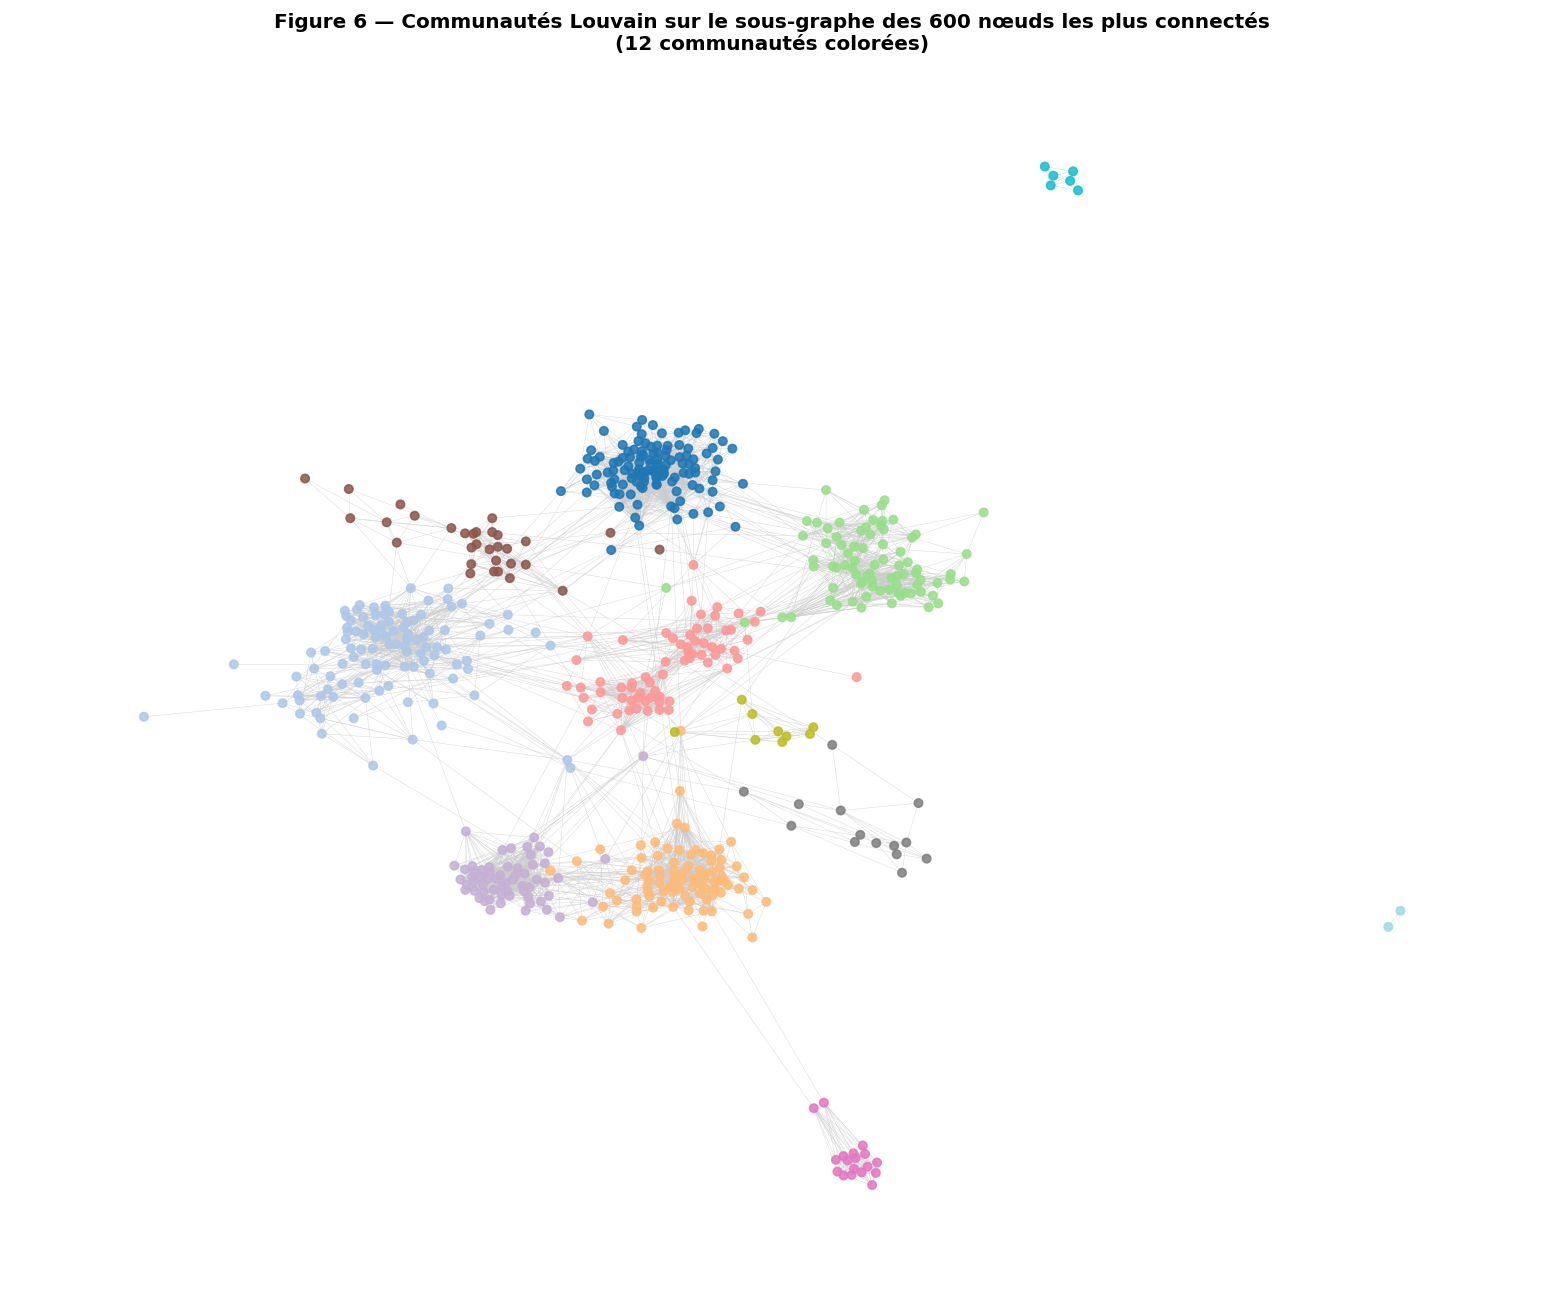

In [68]:
# ── Visualisation du réseau coloré (Louvain, sous-graphe 600 nœuds) ───────────
top_nodes = [n for n, d in sorted(GCC.degree, key=lambda x: x[1], reverse=True)[:600]]
G_viz = GCC.subgraph(top_nodes).copy()
louv_viz = algorithms.louvain(G_viz, randomize=False)

node_comm = {}
for i, comm in enumerate(louv_viz.communities):
    for n in comm: node_comm[n] = i

cmap   = plt.cm.get_cmap('tab20', len(louv_viz.communities))
colors = [cmap(node_comm.get(n, 0)) for n in G_viz.nodes()]
pos    = nx.spring_layout(G_viz, k=0.6, iterations=60, seed=42)

fig, ax = plt.subplots(figsize=(13, 11))
nx.draw_networkx(G_viz, pos=pos, ax=ax, node_color=colors,
                 node_size=25, edge_color='#cccccc', width=0.25,
                 alpha=0.85, with_labels=False)
ax.set_title(f'Figure 6 — Communautés Louvain sur le sous-graphe des 600 nœuds les plus connectés\n({len(louv_viz.communities)} communautés colorées)',
             fontweight='bold', fontsize=12)
ax.axis('off'); plt.tight_layout()
plt.savefig('data/fig6_network_viz.png', bbox_inches='tight', dpi=130); plt.show()

**Interprétation comparative :**

- **Louvain** obtient la modularité Q la plus élevée avec une exécution rapide, produisant des partitions équilibrées. C'est l'algorithme le plus performant sur ce réseau.
- **Label Propagation** est le plus rapide mais moins stable (stochasticité), et tend à produire quelques très grandes communautés dominantes.
- **Infomap** adopte une approche complémentaire basée sur les flux d'information. Il découvre souvent plus de communautés de taille modérée, utile pour révéler la structure interne.
- **K-Clique** est le seul algorithme produisant des communautés chevauchantes, permettant de modéliser des utilisateurs aux goûts musicaux transversaux. Son coût computationnel est plus élevé.

La pureté sémantique des communautés (label dominant > 50%) valide que les groupes détectés correspondent à des regroupements réels d'utilisateurs partageant une localisation géographique similaire, et par extension des préférences musicales proches.

---
<a id='conclusion'></a>
# Conclusion

Ce projet a permis d'analyser le réseau social **LastFM Asia** sous trois angles complémentaires.

**Structurellement**, le réseau présente toutes les propriétés caractéristiques des grands réseaux sociaux réels : une distribution des degrés hétérogène proche d'une loi de puissance (*scale-free*), un composant géant dominant, un chemin moyen court et un coefficient de clustering élevé (propriétés *small-world*). Ces observations confirment que les utilisateurs de Last.fm en Asie forment une communauté musicale fortement interconnectée où l'information circule rapidement.

**En termes de communautés**, les quatre algorithmes testés révèlent une structure modulaire significative (Q > 0.3). L'algorithme de Louvain offre le meilleur compromis entre qualité de partition et efficacité computationnelle. L'interprétation sémantique montre que les communautés détectées correspondent bien à des regroupements d'utilisateurs partageant un contexte géographique et des goûts musicaux communs, ce qui valide la pertinence du dataset choisi pour cet exercice.

**En perspective**, des pistes d'approfondissement incluent : l'utilisation des vecteurs de features (artistes aimés) pour une détection de communautés enrichie sémantiquement, l'application d'algorithmes d'overlapping avancés (DEMON/Angel), et l'analyse de la robustesse du réseau face à la suppression des nœuds à forte betweenness.

---
<a id='references'></a>
# Références

[1] B. Rozemberczki and R. Sarkar, "Characteristic Functions on Graphs: Birds of a Feather, from Statistical Descriptors to Parametric Models," *CIKM 2020*.  
[2] A.-L. Barabási and R. Albert, "Emergence of Scaling in Random Networks," *Science*, 286, 1999.  
[3] M. E. J. Newman, "The Structure and Function of Complex Networks," *SIAM Review*, 2003.  
[4] D. J. Watts and S. H. Strogatz, "Collective dynamics of 'small-world' networks," *Nature*, 393, 1998.  
[5] S. Fortunato, "Community detection in graphs," *Physics Reports*, 486, 2010.  
[6] G. Rossetti et al., "CDlib: a Python Library to Extract, Compare and Evaluate Communities from Complex Networks," *Applied Network Science*, 2019.  
[7] V. D. Blondel et al., "Fast unfolding of communities in large networks," *J. Stat. Mech.*, 2008.  
[8] U. N. Raghavan et al., "Near linear time algorithm to detect community structures in large-scale networks," *Physical Review E*, 76, 2007.  
[9] M. Rosvall and C. T. Bergstrom, "Maps of random walks on complex networks reveal community structure," *PNAS*, 105(4), 2008.  
[10] G. Palla et al., "Uncovering the overlapping community structure of complex networks in nature and society," *Nature*, 435, 2005.